# ASP3231 2026 Assignment 1

**Name:** Alec Stanley

**ID:** 33963975

**Date:** 27/03/26

In [33]:
# Import various libraries 

import numpy as np
import astropy
import photutils
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
import ccdproc
from ccdproc import CCDData

import matplotlib.pyplot as plt
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg, centroid_sources
from photutils.aperture import CircularAperture, EllipticalAperture
from photutils.aperture import aperture_photometry
import gc                               


# CCD Data

The processing of modern astronomical images uses a series of calibration images, shifting-scaling-combining of images, and photometric and astrometric calibration using stars with well-measured photometry and positions respectively. 

Precise photometry is only possible for those stars that have sufficiently signal-to-noise and that are not saturated (too bright) in the images. As our CCD and CMOS detectors are more sensitive to green and red light than blue light, stars often have higher signal to noise or saturate sooner in the V and R bands than the U and B bands.



## Question 1a (4 marks)

When we combine science exposures, we are often doing this to reduce the relative contribution of random noise from the sky background photons. Provide two reasons why we median combine bias and dark exposures, even though the shutter is closed and there are effectively no incident photons.


## Question 1b (4 marks)

For Vega-based magnitudes, why can we calibrate an arbitrary broadband optical filter using observations of stars that have calibrated UBVRI or Gaia magnitudes?


## Question 1c (4 marks)

When we shift, rotate and interpolate images the standard deviation of our science images drops. Does this alter the signal-to-noise of the stars in our images (justify your answer)?

## Question 1d (4 marks)

In calibrated HR diagrams, saturated stars often have artificially blue colours. Why is this the case?


# Data Processing

Michael is not having much luck processing a science image from the C14 telescope despite having excellent bias, dark and flat images. Each time he tries to process the science image with his own code he misses a key step in the data processing. Images A, B, C and D are the C14 images, with image A being the raw image while images B, C and D are processed images where Michael has missed one (and just one) key step. 

## Question 2a

If Michael was using the image header information (meta data) correctly, how could that be used to check which image processing steps had been skipped?

<font color=green>The image header contains information about what operations have been performed on the image. For example, if the image has been median combined, the header will switch the median combine status from false to true. This indicates whether each process has successfully completed and also prevents the program accidentally performing the same operation twice.

## Question 2b (4 marks)

Inspect image B and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


<font color=green>To inspect the image I will first print out the image's header information. I will also plot the image to see what it looks like.

In [17]:
file_name = "B.fits"
image = CCDData.read(file_name, unit="adu")

In [18]:
if 'SUBBIAS' in image.header:
    print("Bias already subtracted")
if 'SUBDARK' in image.header:
    print("Dark already subtracted")
if 'FLATCOR' in image.header:
    print("Flat correction already applied")

<font color=green>No output. It looks like file header information was not correctly applied. I will assume this is the same for images C and D as well, so I will need to rely on my visual skills

Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


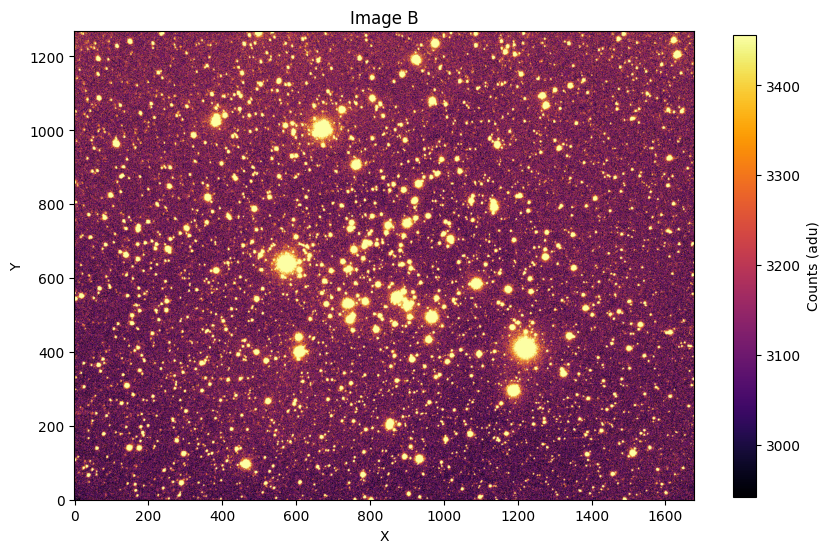

In [38]:
"""
This function will be reused throughout this notebook. It simply plots FITS images.
IN: image as a string or image data. OPTIONAL: title, x label, y label, vmin percent, vmax percent
OUT: image data from CCDData
"""
def simple_fits_imshow(image, title = "Untitled", xlabel = "X", ylabel = "Y", vmin_pc = 5, vmax_pc = 95):
    if isinstance(image, str):
        image = CCDData.read(file_name, unit="adu")
    # Use percentiles to omit the data extremes
    vmin = np.percentile(image.data, vmin_pc)
    vmax = np.percentile(image.data, vmax_pc)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Use inferno colouring. inverting the y-axis to make the origin (0,0)
    plot = ax.imshow(image, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
    fig.colorbar(plot, shrink=0.6, label="Counts (adu)")

    return image

image = simple_fits_imshow(file_name, title = "Image B")

<font color=green>It's clear from this image that the dark has not been subtracted. We don't see dark donuts or vignetting (indicating that the bias has likely been removed and the flats accounted for) so we can conclude that the dark has not been subtracted. This is also confirmed by the obvious presence of hot pixels, which arises due to incident electrons hitting the CCD from the equipment itself. This visual confirmation was undertaken in ds9, comparing all three images side by side.

## Question 2c (4 marks)

Inspect image C and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


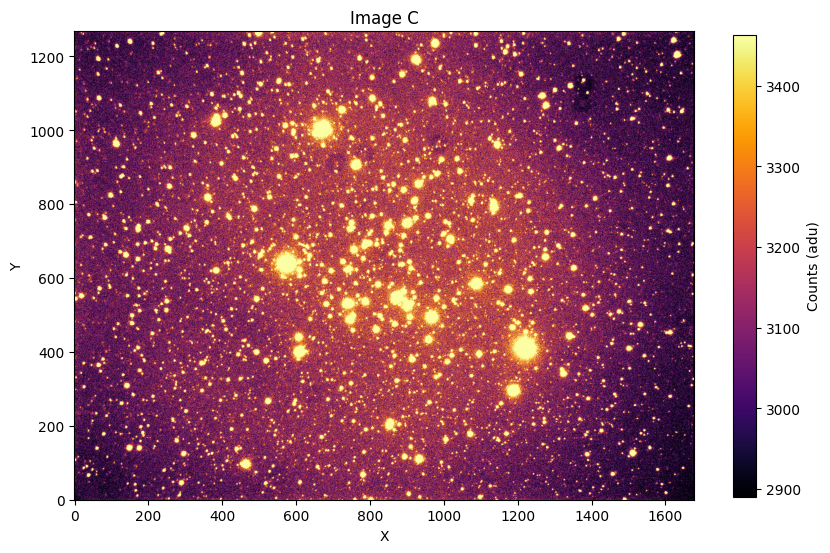

In [29]:
image = simple_fits_imshow("C.fits", title="Image C")

<font color=green>It's clear from this image that the flats have not been corrected. We can see some obvious visual artifacts, including the very clear dark donuts that have appeared (from unfocused particles either on the lens or between the object) as well as a strong vignette effect on the edges of the image. We are told that only one step was missed, so I can conclude that the flats were not corrected for.

## Question 2d (4 marks)

Inspect image D and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


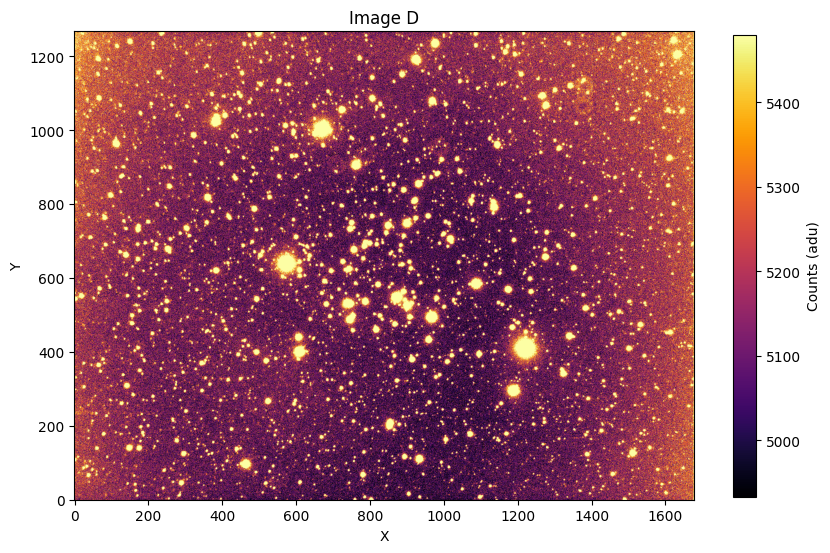

In [30]:
image = simple_fits_imshow("D.fits", title="Image D")

<font color=green>In this image the bias has not been subtracted. We can tell by the very strong light vignette effect on the sides of the image. We don't see any other telltale visual artifacts such as hot pixels or dark donuts that would indicate either the dark or the flat not being corrected for. So I can conclude the bias was not subtracted from this image.

# Noise and Gain

A common method of measuring the gain of a CCD is to use processed flat field images. If the pixel-to-pixel variations are dominated by photon shot noise then:

\begin{equation}
\mu_{photons} = \sigma_{photons}^2
\end {equation}

where $\mu_{photons}$ and $\sigma_{photons}$ are the mean and standard deviation in photons. We can convert this equation to ADU (counts) by putting in the gain, $g$, in electrons per ADU:

\begin{equation}
g \times \mu_{ADU} = g^2 \times \sigma_{ADU}^2
\end {equation}

# Question 3a (9 marks)

We have a raw flat field image, Flat_V_0.900secs_00011010.fit. Please process it using the calibration images provided.

CCDData([[3680.9805 , 3796.931  , 3846.96175, ..., 3423.98875,
          3331.92725, 3479.003  ],
         [3667.97   , 3727.98725, 3842.91675, ..., 3444.94   ,
          3388.00375, 3326.967  ],
         [3807.96625, 3918.946  , 3625.0195 , ..., 3520.01275,
          3423.99775, 3739.003  ],
         ...,
         [3543.95875, 3652.9745 , 3646.952  , ..., 3256.99025,
          3301.93775, 3312.94375],
         [3331.9535 , 3139.95425, 3041.97675, ..., 3296.95125,
          3167.93625, 3469.952  ],
         [3245.97825, 3310.9565 , 3315.9445 , ..., 3238.9415 ,
          3276.98575, 3373.961  ]], shape=(2536, 3358), unit='adu')

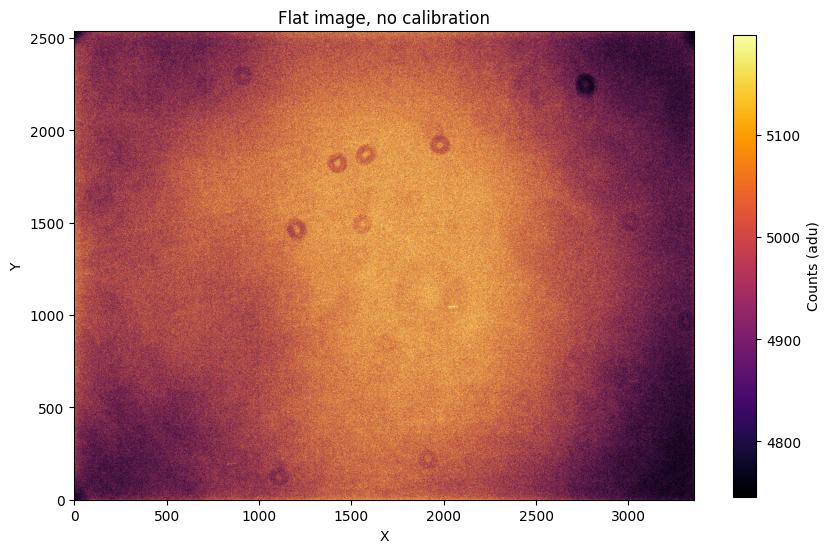

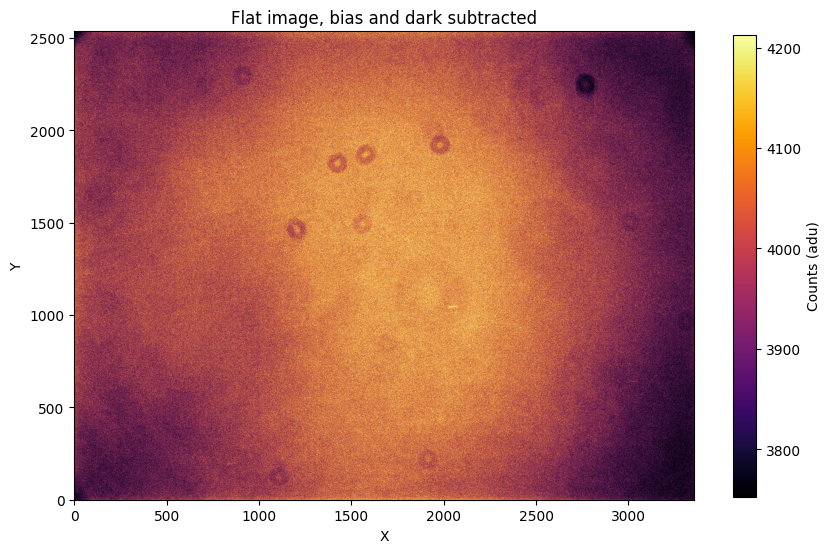

In [42]:
bias_image = CCDData.read("bias_median.fits", unit="adu")
dark_image = CCDData.read("dark_median.fits", unit="adu")
flat_image = CCDData.read("Flat_V_0.900secs_00011010.fit", unit="adu")

simple_fits_imshow(flat_image, title="Flat image, no calibration")

flat_image = ccdproc.subtract_bias(flat_image, bias_image)
flat_image = ccdproc.subtract_dark(flat_image, dark_image, exposure_time = 'EXPTIME', exposure_unit=u.second, scale=True)

simple_fits_imshow(flat_image, title="Flat image, bias and dark subtracted")


## Question 3b (4 marks)

If the gain is on the order of 1, approximately what would the random noise be in this image (in counts)?

## Question 3c (4 marks)

What is the standard deviation of the whole image, and what is the likely cause of the measured standard deviation?

In [37]:
print(np.std(flat_image.data))

140.68801159835212


## Question 3d (6 marks)

Determine the standard deviation for a subregion without obvious feature (like dust doughnuts). What is the standard deviation and its likely cause?

## Question 3e

Determine the gain using the flat field and the measurements you have made of its properties.

# Galaxy photometry 

The Sloan Digital Sky Survey was a benchmark imaging and spectroscopic survey of a quarter of the entire sky. The SDSS images are freely available online and an example - frame-g-003063-3-0047.fits.bz2 - is provided with this notebook. This g-band image shows three galaxies that are part of the Virgo galaxy cluster.

For the following questions you will measure photometry for a galaxy which is assigned based on your student number:

If your student number ends in 0, 1 or 2 use NGC 4440 (x=1117, y=1316)

If your student number ends in 3, 4, 5 or 6 use NGC 4436 (x=1317, y=858)

if your student number ends if 7, 8 or 9 use NGC 4431 (x=1082, y=340)

We can open this image with fits.open without uncompressing it first.


In [ ]:
image = fits.open('frame-g-003063-3-0047.fits.bz2')

# Question 4a - 2 marks

What type of data is image? For example, is it a 2d array of pixel values, a list or something else?

# Question 4b - 4 marks

Display the image with a suitable scaling that shows the random background noise.

# Question 4c - 11 marks

The SDSS images are normalised so the magnitudes are given by 

\begin{equation}
m = 22.5 - 2.5 \times {\rm log} (f_{counts}).
\end{equation}

For the galaxy you have been assigned above measure the centroid and a 30 pixel radius aperture magnitude.

(You may want to compare with this literature values and consider whether you expect this magnitude to be brighter or fainter than the literature.)

# Question 4d - 13 marks

An elliptical aperture can produce more accurate galaxy photometry than a circular aperture. Define a suitable elliptical aperture for your galaxy, and measure the magnitude.
    
Hint: You may want to overplot the ellipse on the image by adapting the code below.

In [ ]:
# Plot an ellipse 

x=1000
y=1000
ia=50
ib=20
theta=30.0*np.pi/180.0
px=[]
py=[]
t=0.0
while t<2.01*np.pi:
    px.append(x + ia*np.cos(t)*np.cos(theta) - ib*np.sin(t)*np.sin(theta))
    py.append(y + ia*np.cos(t)*np.sin(theta) + ib*np.sin(t)*np.cos(theta))
    t=t+0.05
plt.plot(px,py)

## Exercise (not marked)

One way to determine the ideal aperture size is to use a series of apertures and find the asymptotic magnitude. There will be a sweet spot where the magnitude is stable (or close to it) as a function of aperture size before random noise and source confusion cause the magnitude to start a random walk. You could try implementing this for your galaxy to see this in action.